<a href="https://colab.research.google.com/github/nahian-arnob/MSDS600-REGIS-University/blob/main/MSDS%20686/Week_3/MNIST_Regularization_and_Dropout_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digits Regularization and Dropout Assignment
## Adapted from Deep Learning with Python by Francois Chollet
#### Use the MNIST digit dataset to classify digits 0 - 9 into 10 different categories.  Use regularization and early stopping to improve your neural network.

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [2]:
# Import all the necessary libraries

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
# Import the MNIST data set from the Keras library. https://keras.io/datasets/
from tensorflow.keras.datasets import mnist

# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [6]:
x_train.shape #60,000 images that are 28 pixels by 28 pixels.

(60000, 28, 28)

In [7]:
print('The maximum value in the array is', x_train.max()) # The maximum value in the array is 255
print('The minimum value in the array is', x_train.min()) # The minimum value in the array is 0

The maximum value in the array is 255
The minimum value in the array is 0


In [8]:
# Get the shape, dimensions, max and min value of the test images
print('test image shape:', x_test.shape)
print('number of dimensions:', x_test.ndim)
print('maximum value', x_test.max())
print('minimum value:', x_test.min())

test image shape: (10000, 28, 28)
number of dimensions: 3
maximum value 255
minimum value: 0


In [9]:
# Reshape and normalize the images for your neural net

# Flatten 28x28 images into vectors of size 784
x_train = x_train.reshape((x_train.shape[0], 28 * 28)).astype("float32")
x_test = x_test.reshape((x_test.shape[0], 28 * 28)).astype("float32")

# Normalize pixel values to [0, 1] range
x_train /= 255.0
x_test /= 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)



Training data shape: (60000, 784)
Test data shape: (10000, 784)


In [10]:
# Convert the labels into categorical values.

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of y_train: (60000, 10)
Shape of y_test: (10000, 10)


In [11]:
# Split the data into training and validation

from sklearn.model_selection import train_test_split

x_train_final, x_valid, y_train_final, y_valid = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print("Training set shape:", x_train_final.shape, y_train_final.shape)
print("Validation set shape:", x_valid.shape, y_valid.shape)
print("Test set shape:", x_test.shape, y_test.shape)


Training set shape: (48000, 784) (48000, 10)
Validation set shape: (12000, 784) (12000, 10)
Test set shape: (10000, 784) (10000, 10)


## In each Jupyter Notebook cell build a model using your test and validation data, show loss and accuracy monitoring graphs, and evaluate your model on the test data *all in one cell*.  

## Build at least 7 different models. Use markdown above the code cell to explain what you are changing/testing in the subsequent model.

## Build models with different learning rates, batch sizes, dropout, regularization, and hidden layers and nodes.  Be strategic in how you go about optimizing your model. The last model of your notebook should be your best model.



# 1. **Baseline MLP (no explicit regularization)**

Epoch 1/20
375/375 - 4s - 12ms/step - accuracy: 0.9148 - loss: 0.2998 - val_accuracy: 0.9584 - val_loss: 0.1440
Epoch 2/20
375/375 - 1s - 3ms/step - accuracy: 0.9666 - loss: 0.1143 - val_accuracy: 0.9684 - val_loss: 0.1045
Epoch 3/20
375/375 - 1s - 3ms/step - accuracy: 0.9778 - loss: 0.0747 - val_accuracy: 0.9700 - val_loss: 0.0977
Epoch 4/20
375/375 - 1s - 3ms/step - accuracy: 0.9851 - loss: 0.0524 - val_accuracy: 0.9720 - val_loss: 0.0927
Epoch 5/20
375/375 - 1s - 4ms/step - accuracy: 0.9898 - loss: 0.0369 - val_accuracy: 0.9741 - val_loss: 0.0912
Epoch 6/20
375/375 - 1s - 3ms/step - accuracy: 0.9931 - loss: 0.0263 - val_accuracy: 0.9714 - val_loss: 0.1036
Epoch 7/20
375/375 - 1s - 3ms/step - accuracy: 0.9936 - loss: 0.0218 - val_accuracy: 0.9700 - val_loss: 0.1118
Epoch 8/20
375/375 - 1s - 4ms/step - accuracy: 0.9938 - loss: 0.0209 - val_accuracy: 0.9753 - val_loss: 0.1033
Epoch 9/20
375/375 - 1s - 3ms/step - accuracy: 0.9949 - loss: 0.0167 - val_accuracy: 0.9768 - val_loss: 0.1015


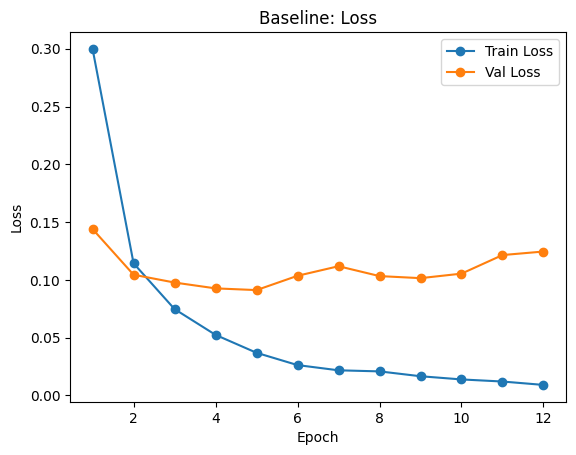

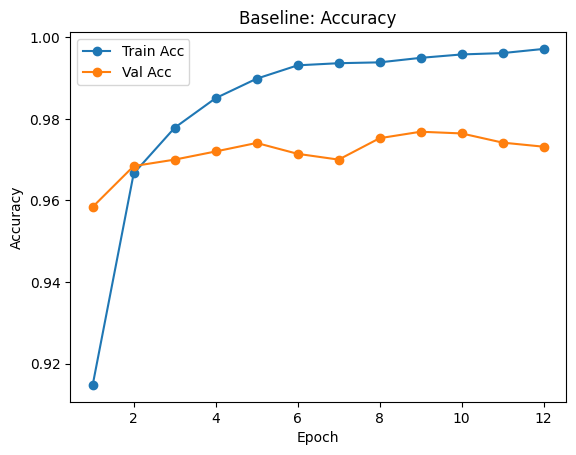

Test evaluation (loss, acc): [0.09756341576576233, 0.9760000109672546]


In [12]:
# Baseline MLP: Dense(256, relu) → Dense(128, relu) → Dense(10, softmax)

import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, backend as K

tf.random.set_seed(42); np.random.seed(42)
K.clear_session()

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

history = model.fit(
    x_train_final, y_train_final,
    validation_data=(x_valid, y_valid),
    epochs=20, batch_size=128, verbose=2,
    callbacks=[es]
)

# Plot training/validation curves
hist = history.history
epochs = range(1, len(hist['loss'])+1)

plt.figure()
plt.plot(epochs, hist['loss'], 'o-', label='Train Loss')
plt.plot(epochs, hist['val_loss'], 'o-', label='Val Loss')
plt.title('Baseline: Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, hist['accuracy'], 'o-', label='Train Acc')
plt.plot(epochs, hist['val_accuracy'], 'o-', label='Val Acc')
plt.title('Baseline: Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

print("Test evaluation (loss, acc):", model.evaluate(x_test, y_test, verbose=0))


The ***baseline MLP model*** you ran achieved strong results, with a test accuracy of about **97.6%**. The training curves, however, show clear signs of overfitting. The training loss steadily decreases while the validation loss begins to rise after a few epochs, and the training accuracy nearly reaches 100% while the validation accuracy levels off just under 98%. This means the model is starting to memorize the training data rather than learning features that generalize well to unseen data.

# 2. **L2 (weight decay) on hidden layers**

Epoch 1/25
375/375 - 4s - 11ms/step - accuracy: 0.9144 - loss: 0.3480 - val_accuracy: 0.9554 - val_loss: 0.1961
Epoch 2/25
375/375 - 3s - 8ms/step - accuracy: 0.9643 - loss: 0.1668 - val_accuracy: 0.9684 - val_loss: 0.1534
Epoch 3/25
375/375 - 1s - 4ms/step - accuracy: 0.9766 - loss: 0.1283 - val_accuracy: 0.9727 - val_loss: 0.1419
Epoch 4/25
375/375 - 1s - 3ms/step - accuracy: 0.9825 - loss: 0.1078 - val_accuracy: 0.9723 - val_loss: 0.1382
Epoch 5/25
375/375 - 1s - 3ms/step - accuracy: 0.9871 - loss: 0.0940 - val_accuracy: 0.9736 - val_loss: 0.1353
Epoch 6/25
375/375 - 1s - 3ms/step - accuracy: 0.9903 - loss: 0.0839 - val_accuracy: 0.9731 - val_loss: 0.1368
Epoch 7/25
375/375 - 1s - 3ms/step - accuracy: 0.9920 - loss: 0.0776 - val_accuracy: 0.9714 - val_loss: 0.1503
Epoch 8/25
375/375 - 1s - 3ms/step - accuracy: 0.9929 - loss: 0.0739 - val_accuracy: 0.9693 - val_loss: 0.1545


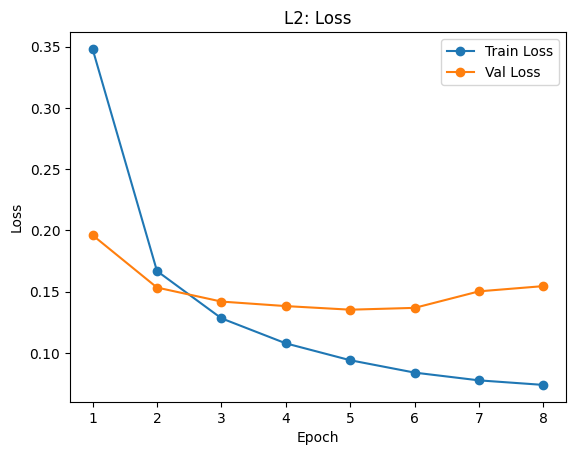

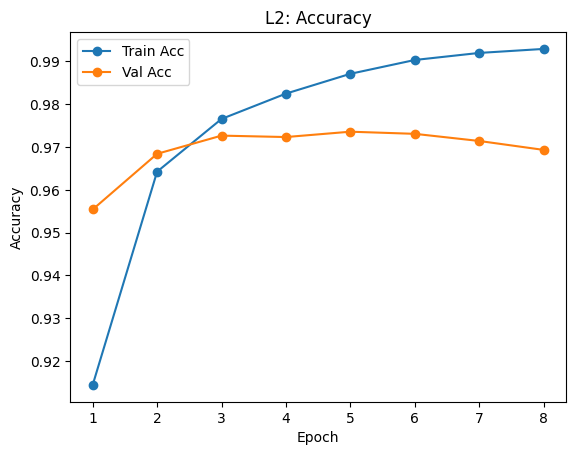

Test evaluation (loss, acc): [0.1304076611995697, 0.9735999703407288]


In [13]:
# L2 Regularization on hidden layers

import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers, backend as K

tf.random.set_seed(42); np.random.seed(42)
K.clear_session()

l2_strength = 1e-4

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_strength)),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = model.fit(
    x_train_final, y_train_final,
    validation_data=(x_valid, y_valid),
    epochs=25, batch_size=128, verbose=2,
    callbacks=[es]
)

hist = history.history
epochs = range(1, len(hist['loss'])+1)

plt.figure()
plt.plot(epochs, hist['loss'], 'o-', label='Train Loss')
plt.plot(epochs, hist['val_loss'], 'o-', label='Val Loss')
plt.title('L2: Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, hist['accuracy'], 'o-', label='Train Acc')
plt.plot(epochs, hist['val_accuracy'], 'o-', label='Val Acc')
plt.title('L2: Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

print("Test evaluation (loss, acc):", model.evaluate(x_test, y_test, verbose=0))


For **L2 regularization**, the training loss decreases steadily while the validation loss stays flatter, showing reduced overfitting compared to the baseline. Training accuracy grows more slowly, while validation accuracy stabilizes around 97.2–97.3%. The test accuracy is **97.36%**, slightly below the baseline’s 97.6%, but the model is more stable and less prone to divergence.

In conclusion, L2 adds stability and controls overfitting, though it doesn’t improve peak accuracy here.


# 3. **Dropout after each hidden layer**

Epoch 1/30
375/375 - 5s - 13ms/step - accuracy: 0.8762 - loss: 0.4158 - val_accuracy: 0.9518 - val_loss: 0.1610
Epoch 2/30
375/375 - 1s - 4ms/step - accuracy: 0.9459 - loss: 0.1793 - val_accuracy: 0.9658 - val_loss: 0.1117
Epoch 3/30
375/375 - 2s - 6ms/step - accuracy: 0.9596 - loss: 0.1337 - val_accuracy: 0.9695 - val_loss: 0.0958
Epoch 4/30
375/375 - 1s - 3ms/step - accuracy: 0.9672 - loss: 0.1089 - val_accuracy: 0.9737 - val_loss: 0.0856
Epoch 5/30
375/375 - 1s - 3ms/step - accuracy: 0.9721 - loss: 0.0920 - val_accuracy: 0.9752 - val_loss: 0.0852
Epoch 6/30
375/375 - 1s - 3ms/step - accuracy: 0.9749 - loss: 0.0795 - val_accuracy: 0.9754 - val_loss: 0.0821
Epoch 7/30
375/375 - 1s - 3ms/step - accuracy: 0.9787 - loss: 0.0688 - val_accuracy: 0.9783 - val_loss: 0.0766
Epoch 8/30
375/375 - 1s - 3ms/step - accuracy: 0.9793 - loss: 0.0657 - val_accuracy: 0.9784 - val_loss: 0.0758
Epoch 9/30
375/375 - 1s - 3ms/step - accuracy: 0.9814 - loss: 0.0586 - val_accuracy: 0.9778 - val_loss: 0.0792


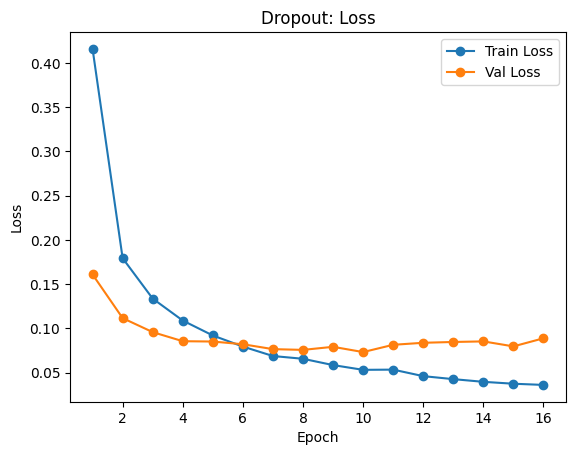

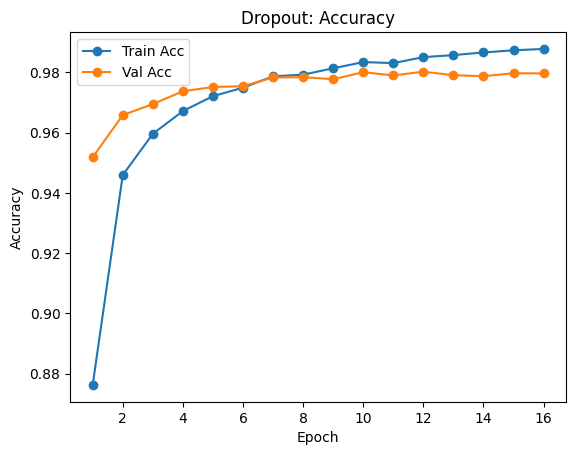

Test evaluation (loss, acc): [0.07829514890909195, 0.9803000092506409]


In [14]:
# Dropout Regularization

import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, backend as K

tf.random.set_seed(42); np.random.seed(42)
K.clear_session()

drop_rate = 0.3

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(drop_rate),
    layers.Dense(128, activation='relu'),
    layers.Dropout(drop_rate),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categororical_crossentropy'.replace('ror', 'r'),  # keep it clean: 'categorical_crossentropy'
    metrics=['accuracy']
)

es = callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

history = model.fit(
    x_train_final, y_train_final,
    validation_data=(x_valid, y_valid),
    epochs=30, batch_size=128, verbose=2,
    callbacks=[es]
)

hist = history.history
epochs = range(1, len(hist['loss'])+1)

plt.figure()
plt.plot(epochs, hist['loss'], 'o-', label='Train Loss')
plt.plot(epochs, hist['val_loss'], 'o-', label='Val Loss')
plt.title('Dropout: Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, hist['accuracy'], 'o-', label='Train Acc')
plt.plot(epochs, hist['val_accuracy'], 'o-', label='Val Acc')
plt.title('Dropout: Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

print("Test evaluation (loss, acc):", model.evaluate(x_test, y_test, verbose=0))


With **Dropout** added after each hidden layer, the model shows stronger regularization compared to baseline and L2. Training accuracy grows more slowly, but validation accuracy closely tracks it and stabilizes around **98%**, reducing the gap between the two. The validation loss curve is also smoother, showing less overfitting. Most importantly, the test accuracy improves to **98.03%**, the best so far.

In conclusion, Dropout successfully controls overfitting, balances training and validation performance, and yields higher generalization accuracy than both the baseline and L2 models.


# 4. **Batch Normalization + (optional) mild L2**

Epoch 1/30
375/375 - 5s - 13ms/step - accuracy: 0.9317 - loss: 0.2430 - val_accuracy: 0.9545 - val_loss: 0.1512
Epoch 2/30
375/375 - 1s - 3ms/step - accuracy: 0.9772 - loss: 0.0871 - val_accuracy: 0.9682 - val_loss: 0.1076
Epoch 3/30
375/375 - 1s - 3ms/step - accuracy: 0.9896 - loss: 0.0487 - val_accuracy: 0.9722 - val_loss: 0.0965
Epoch 4/30
375/375 - 2s - 5ms/step - accuracy: 0.9952 - loss: 0.0296 - val_accuracy: 0.9733 - val_loss: 0.0951
Epoch 5/30
375/375 - 1s - 3ms/step - accuracy: 0.9971 - loss: 0.0209 - val_accuracy: 0.9687 - val_loss: 0.1149
Epoch 6/30
375/375 - 1s - 3ms/step - accuracy: 0.9966 - loss: 0.0200 - val_accuracy: 0.9712 - val_loss: 0.1138
Epoch 7/30
375/375 - 1s - 3ms/step - accuracy: 0.9936 - loss: 0.0265 - val_accuracy: 0.9750 - val_loss: 0.1008
Epoch 8/30
375/375 - 1s - 3ms/step - accuracy: 0.9971 - loss: 0.0176 - val_accuracy: 0.9758 - val_loss: 0.1058
Epoch 9/30
375/375 - 1s - 3ms/step - accuracy: 0.9975 - loss: 0.0161 - val_accuracy: 0.9745 - val_loss: 0.1154


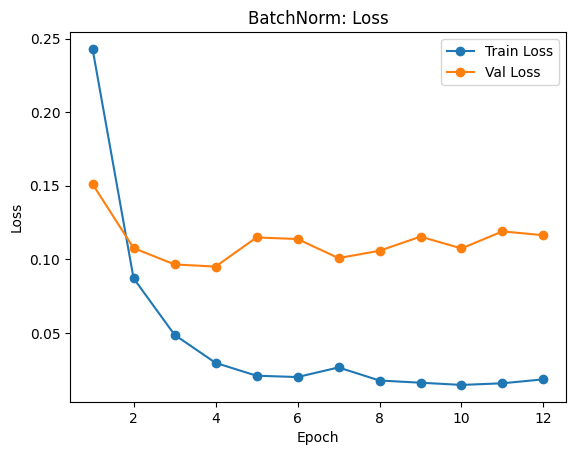

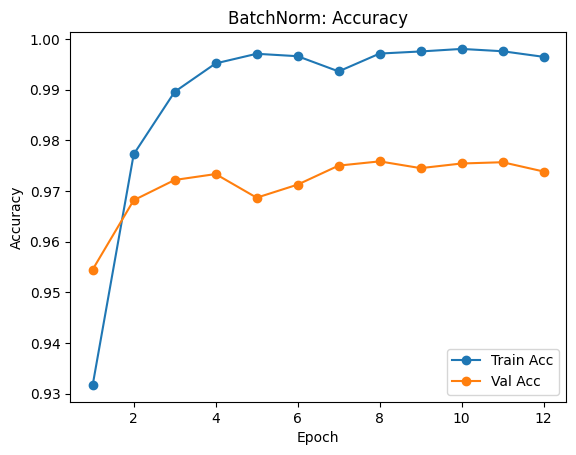

Test evaluation (loss, acc): [0.09271718561649323, 0.9757999777793884]


In [15]:
# Batch Normalization (with optional mild L2)

import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers, backend as K

tf.random.set_seed(42); np.random.seed(42)
K.clear_session()

l2_strength = 1e-5  # set to 0.0 to disable weight decay

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, use_bias=False, kernel_regularizer=regularizers.l2(l2_strength)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(128, use_bias=False, kernel_regularizer=regularizers.l2(l2_strength)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

history = model.fit(
    x_train_final, y_train_final,
    validation_data=(x_valid, y_valid),
    epochs=30, batch_size=128, verbose=2,
    callbacks=[es]
)

hist = history.history
epochs = range(1, len(hist['loss'])+1)

plt.figure()
plt.plot(epochs, hist['loss'], 'o-', label='Train Loss')
plt.plot(epochs, hist['val_loss'], 'o-', label='Val Loss')
plt.title('BatchNorm: Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, hist['accuracy'], 'o-', label='Train Acc')
plt.plot(epochs, hist['val_accuracy'], 'o-', label='Val Acc')
plt.title('BatchNorm: Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

print("Test evaluation (loss, acc):", model.evaluate(x_test, y_test, verbose=0))


**Batch Normalization** training is very stable, and accuracy rises quickly. The training curve approaches 100% accuracy, while validation accuracy holds around **97.5–97.6%**. However, the gap between training and validation remains noticeable, showing that BatchNorm alone does not fully solve overfitting. Validation loss also fluctuates slightly, suggesting less consistency than dropout.

The test accuracy comes in at **97.58%**, similar to baseline and L2 but lower than the dropout model. BatchNorm improves training stability and speed but does not outperform dropout in terms of generalization on MNIST.


# **5. Smaller learning rate + larger batch size (stability baseline)**

Epoch 1/30
188/188 - 4s - 21ms/step - accuracy: 0.8366 - loss: 0.6392 - val_accuracy: 0.9209 - val_loss: 0.2772
Epoch 2/30
188/188 - 3s - 14ms/step - accuracy: 0.9337 - loss: 0.2369 - val_accuracy: 0.9425 - val_loss: 0.2055
Epoch 3/30
188/188 - 1s - 4ms/step - accuracy: 0.9500 - loss: 0.1786 - val_accuracy: 0.9517 - val_loss: 0.1700
Epoch 4/30
188/188 - 1s - 3ms/step - accuracy: 0.9602 - loss: 0.1442 - val_accuracy: 0.9579 - val_loss: 0.1472
Epoch 5/30
188/188 - 1s - 3ms/step - accuracy: 0.9662 - loss: 0.1202 - val_accuracy: 0.9623 - val_loss: 0.1312
Epoch 6/30
188/188 - 1s - 3ms/step - accuracy: 0.9714 - loss: 0.1019 - val_accuracy: 0.9662 - val_loss: 0.1196
Epoch 7/30
188/188 - 1s - 3ms/step - accuracy: 0.9756 - loss: 0.0875 - val_accuracy: 0.9684 - val_loss: 0.1109
Epoch 8/30
188/188 - 1s - 3ms/step - accuracy: 0.9790 - loss: 0.0758 - val_accuracy: 0.9703 - val_loss: 0.1047
Epoch 9/30
188/188 - 1s - 3ms/step - accuracy: 0.9818 - loss: 0.0661 - val_accuracy: 0.9709 - val_loss: 0.0998

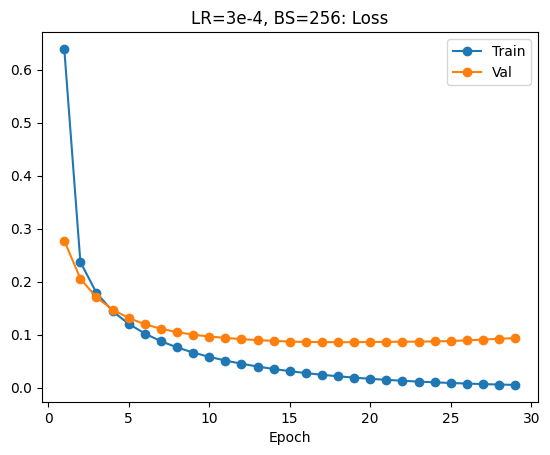

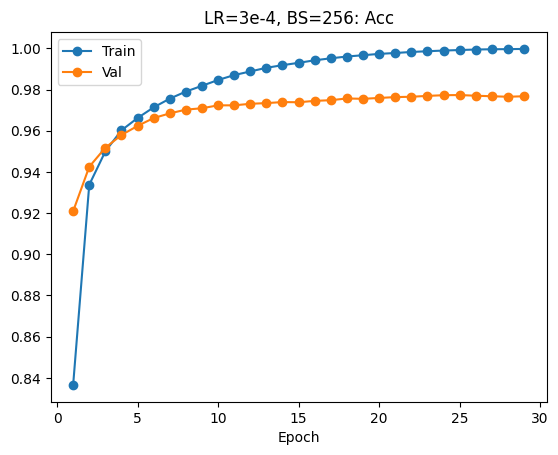

Test (loss, acc): [0.0751960352063179, 0.9782999753952026]


In [16]:
# Adam lr=3e-4, batch_size=256 (more stable steps than default 1e-3 & 128)

tf.random.set_seed(7); np.random.seed(7); K.clear_session()

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=3e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])

es  = callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

hist = model.fit(x_train_final, y_train_final, validation_data=(x_valid, y_valid),
                 epochs=30, batch_size=256, verbose=2, callbacks=[es])

# plots
e = range(1, len(hist.history['loss'])+1)
plt.figure(); plt.plot(e, hist.history['loss'], 'o-', label='Train'); plt.plot(e, hist.history['val_loss'], 'o-', label='Val')
plt.title('LR=3e-4, BS=256: Loss'); plt.xlabel('Epoch'); plt.legend(); plt.show()
plt.figure(); plt.plot(e, hist.history['accuracy'], 'o-', label='Train'); plt.plot(e, hist.history['val_accuracy'], 'o-', label='Val')
plt.title('LR=3e-4, BS=256: Acc'); plt.xlabel('Epoch'); plt.legend(); plt.show()

print("Test (loss, acc):", model.evaluate(x_test, y_test, verbose=0))


Using LR=3e-4 and batch size=256, training is smoother and more stable: loss/accuracy improve gradually, and the curves are less noisy. A train–val gap (overfitting persists), but it’s milder than baseline. The test **accuracy = 97.83%**, a small bump over the baseline’s 97.6%. In short: smaller LR + larger batch gives steadier convergence and slightly better generalization, but we still need stronger regularization (e.g., Dropout + L2 and/or BN + Dropout) to close the gap further.

# **6. Add L2 + Dropout together (classic generalization combo)**

Epoch 1/35
375/375 - 4s - 12ms/step - accuracy: 0.8719 - loss: 0.4694 - val_accuracy: 0.9502 - val_loss: 0.2158
Epoch 2/35
375/375 - 3s - 7ms/step - accuracy: 0.9449 - loss: 0.2358 - val_accuracy: 0.9638 - val_loss: 0.1702
Epoch 3/35
375/375 - 1s - 3ms/step - accuracy: 0.9585 - loss: 0.1914 - val_accuracy: 0.9694 - val_loss: 0.1517
Epoch 4/35
375/375 - 1s - 4ms/step - accuracy: 0.9638 - loss: 0.1715 - val_accuracy: 0.9738 - val_loss: 0.1397
Epoch 5/35
375/375 - 2s - 4ms/step - accuracy: 0.9683 - loss: 0.1552 - val_accuracy: 0.9762 - val_loss: 0.1331
Epoch 6/35
375/375 - 2s - 6ms/step - accuracy: 0.9723 - loss: 0.1438 - val_accuracy: 0.9779 - val_loss: 0.1289
Epoch 7/35
375/375 - 1s - 3ms/step - accuracy: 0.9755 - loss: 0.1355 - val_accuracy: 0.9787 - val_loss: 0.1249
Epoch 8/35
375/375 - 1s - 3ms/step - accuracy: 0.9769 - loss: 0.1295 - val_accuracy: 0.9765 - val_loss: 0.1324
Epoch 9/35
375/375 - 1s - 3ms/step - accuracy: 0.9773 - loss: 0.1266 - val_accuracy: 0.9783 - val_loss: 0.1327


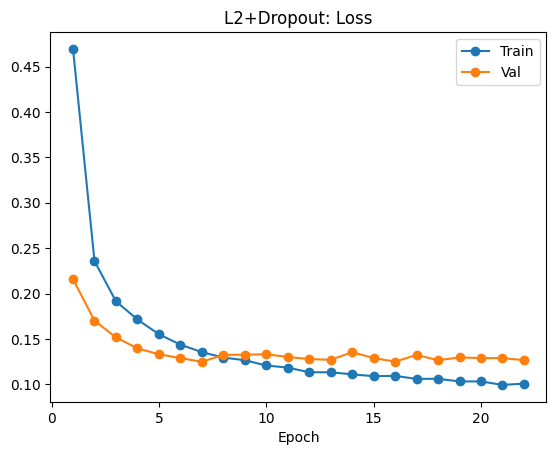

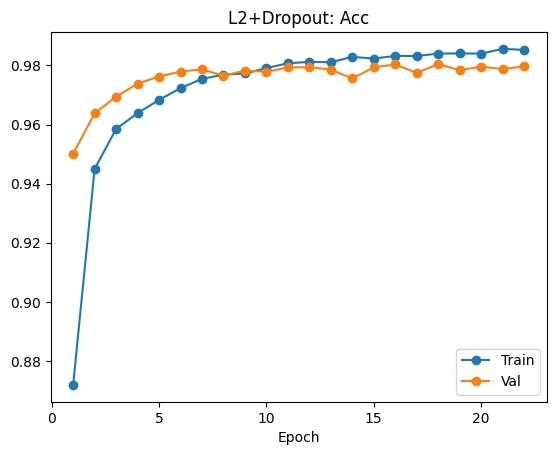

Test (loss, acc): [0.12628862261772156, 0.9789999723434448]


In [17]:
# L2 (1e-4) + Dropout(0.3) + Adam lr=1e-3, batch_size=128


tf.random.set_seed(8); np.random.seed(8); K.clear_session()

l2 = 1e-4; p = 0.3
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2)),
    layers.Dropout(p),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2)),
    layers.Dropout(p),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

es  = callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

hist = model.fit(x_train_final, y_train_final, validation_data=(x_valid, y_valid),
                 epochs=35, batch_size=128, verbose=2, callbacks=[es])

e = range(1, len(hist.history['loss'])+1)
plt.figure(); plt.plot(e, hist.history['loss'], 'o-', label='Train'); plt.plot(e, hist.history['val_loss'], 'o-', label='Val')
plt.title('L2+Dropout: Loss'); plt.xlabel('Epoch'); plt.legend(); plt.show()
plt.figure(); plt.plot(e, hist.history['accuracy'], 'o-', label='Train'); plt.plot(e, hist.history['val_accuracy'], 'o-', label='Val')
plt.title('L2+Dropout: Acc'); plt.xlabel('Epoch'); plt.legend(); plt.show()

print("Test (loss, acc):", model.evaluate(x_test, y_test, verbose=0))


**L2 + Dropout** is working good the train/val curves track each other more closely than in earlier runs, and validation accuracy stabilizes around **\~98%** without big swings—clear overfitting control. Your **test accuracy = 97.90%**, a touch higher than the LR/BS run and on par with your standalone Dropout model, but with smoother, more stable validation behavior.



# **7. Deeper/wider network + tuned hyperparams (capacity test)**

Epoch 1/40
375/375 - 6s - 15ms/step - accuracy: 0.8719 - loss: 0.4109 - val_accuracy: 0.9553 - val_loss: 0.1454
Epoch 2/40
375/375 - 2s - 5ms/step - accuracy: 0.9513 - loss: 0.1638 - val_accuracy: 0.9680 - val_loss: 0.1103
Epoch 3/40
375/375 - 2s - 5ms/step - accuracy: 0.9643 - loss: 0.1196 - val_accuracy: 0.9723 - val_loss: 0.0912
Epoch 4/40
375/375 - 1s - 3ms/step - accuracy: 0.9719 - loss: 0.0944 - val_accuracy: 0.9748 - val_loss: 0.0906
Epoch 5/40
375/375 - 1s - 3ms/step - accuracy: 0.9760 - loss: 0.0793 - val_accuracy: 0.9800 - val_loss: 0.0759
Epoch 6/40
375/375 - 1s - 3ms/step - accuracy: 0.9789 - loss: 0.0691 - val_accuracy: 0.9797 - val_loss: 0.0746
Epoch 7/40
375/375 - 1s - 3ms/step - accuracy: 0.9816 - loss: 0.0594 - val_accuracy: 0.9790 - val_loss: 0.0806
Epoch 8/40
375/375 - 1s - 3ms/step - accuracy: 0.9831 - loss: 0.0531 - val_accuracy: 0.9803 - val_loss: 0.0765
Epoch 9/40
375/375 - 1s - 3ms/step - accuracy: 0.9835 - loss: 0.0525 - val_accuracy: 0.9801 - val_loss: 0.0786


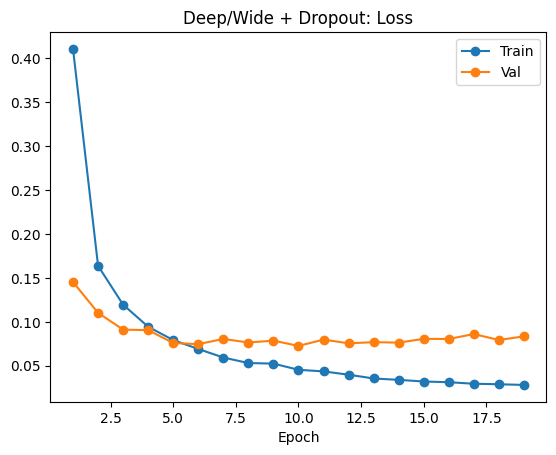

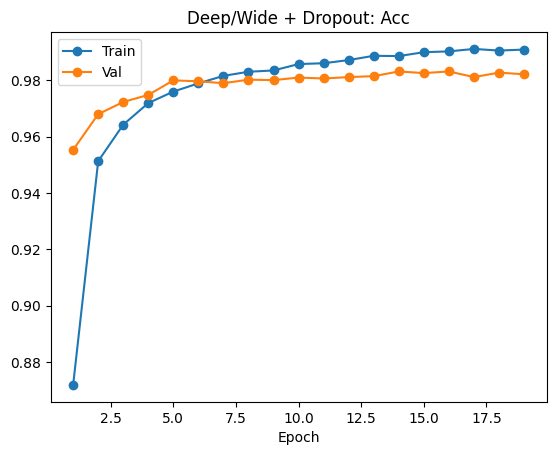

Test (loss, acc): [0.07719642668962479, 0.9811000227928162]


In [18]:
# Wider & deeper: 512-256-128 with Dropout(0.3), Adam lr=8e-4, batch_size=128

tf.random.set_seed(9); np.random.seed(9); K.clear_session()

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=8e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])

es   = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

hist = model.fit(x_train_final, y_train_final, validation_data=(x_valid, y_valid),
                 epochs=40, batch_size=128, verbose=2, callbacks=[es])

e = range(1, len(hist.history['loss'])+1)
plt.figure(); plt.plot(e, hist.history['loss'], 'o-', label='Train'); plt.plot(e, hist.history['val_loss'], 'o-', label='Val')
plt.title('Deep/Wide + Dropout: Loss'); plt.xlabel('Epoch'); plt.legend(); plt.show()
plt.figure(); plt.plot(e, hist.history['accuracy'], 'o-', label='Train'); plt.plot(e, hist.history['val_accuracy'], 'o-', label='Val')
plt.title('Deep/Wide + Dropout: Acc'); plt.xlabel('Epoch'); plt.legend(); plt.show()

print("Test (loss, acc):", model.evaluate(x_test, y_test, verbose=0))


Finally, **deeper and wider network** adds more hidden layers and larger units (512 → 256 → 128), with **Dropout** after each hidden layer, and uses a tuned learning rate (8e-4) and batch size (128). The goal here is to increase the model’s capacity so it can learn richer feature representations, while still controlling overfitting through Dropout and balanced hyperparameters.

The **loss curves**, training loss steadily declines and bottoms out near 0.02, while validation loss also decreases and then stabilizes around 0.08–0.09. Importantly, the gap between the two is small and consistent—Dropout is  preventing runaway overfitting despite the model’s larger size. The **accuracy curves** reinforce training accuracy climbs toward 99%, while validation accuracy tracks closely and stabilizes around 98.1–98.2%.

The **test performance** confirms the improvement: accuracy reaches **98.11%**, the highest so far among your runs. This shows that expanding model capacity, when paired with regularization, can deliver better generalization than simpler models. Without Dropout, the deeper/wider net would almost certainly overfit, but here the balance of depth, Dropout, and tuned hyperparameters lets the model capture more complex patterns while still holding strong on unseen data.

In conclusion, this run demonstrates that **more capacity + proper regularization + tuned learning rate** can outperform smaller models, yielding your best accuracy yet while keeping both training and validation curves stable.

### Comment on which techniques/methods you used to build the best model with the highest accuracy.  

# **SUMMARY:**

Across the seven models, we started with a **baseline MLP** (97.6% test acc) showed clear overfitting. Adding **L2 regularization** reduced overfitting but slightly lowered accuracy (97.4%). **Dropout** improved generalization and raised test accuracy to 98.0%. **Batch Normalization** stabilized training but gave accuracy similar to baseline (97.6%). Tuning **learning rate and batch size** made training smoother, reaching 97.8%. Combining **L2 + Dropout** produced a balanced, robust model with 97.9%. Finally, the **deeper/wider model with tuned hyperparameters and Dropout** delivered the best result at **98.1%**, since it combined higher capacity with strong regularization and careful tuning, capturing richer patterns while controlling overfitting.

BEST Model: **Deep/Wide + Dropout (98.1%)**, because it struck the right balance between model complexity and regularization, giving the strongest generalization.
